In [ ]:
# ─── CELL 1: Setup + Load ───────────────────────────────────────────────────
!pip install -q sentence-transformers openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from google.colab import drive
import warnings
warnings.filterwarnings("ignore")

# ── Paths — adjust if yours differ ──────────────────────────────────────────
HUMAID_TRAIN = "/content/all_train.tsv"
HUMAID_DEV   = "/content/all_dev.tsv"
HUMAID_TEST  = "/content/all_test.tsv"

# Upload Question_Bank_Curation.xlsx to your Drive and set path:
QB_CURATION  = "/content/Question_Bank_Curation.xlsx"

# ── Load HumAID ──────────────────────────────────────────────────────────────
humaid = pd.concat([
    pd.read_csv(HUMAID_TRAIN, sep="\t"),
    pd.read_csv(HUMAID_DEV,   sep="\t"),
    pd.read_csv(HUMAID_TEST,  sep="\t"),
], ignore_index=True)

humaid = humaid.dropna(subset=["tweet_text", "class_label"])
humaid = humaid[humaid["class_label"] != "not_humanitarian"].reset_index(drop=True)

print(f"HumAID: {len(humaid):,} humanitarian tweets across {humaid['class_label'].nunique()} labels")

# ── Load Form A curated questions (FINAL BANK sheet) ────────────────────────
qb = pd.read_excel(QB_CURATION, sheet_name="FINAL BANK", header=1)
qb.columns = ["Q_num", "Type", "Scenario", "Question", "Notes"]
qb = qb[qb["Question"].notna() & (qb["Question"].str.strip() != "")].reset_index(drop=True)

print(f"Form A Question Bank: {len(qb)} questions")
print(qb["Type"].value_counts().to_string())

HumAID: 70,170 humanitarian tweets across 9 labels
Form A Question Bank: 100 questions
Type
FACTUAL         25
PROCEDURAL      25
ADVISORY        25
HYPOTHETICAL    25


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Model loaded: sentence-transformers/all-MiniLM-L6-v2
Embedding HumAID tweets...


Batches:   0%|          | 0/59 [00:00<?, ?it/s]

Clustering...
Embedding Form A questions...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


Cluster → Question Type mapping:
  Cluster 0 → FACTUAL
  Cluster 1 → ADVISORY
  Cluster 2 → HYPOTHETICAL
  Cluster 3 → PROCEDURAL


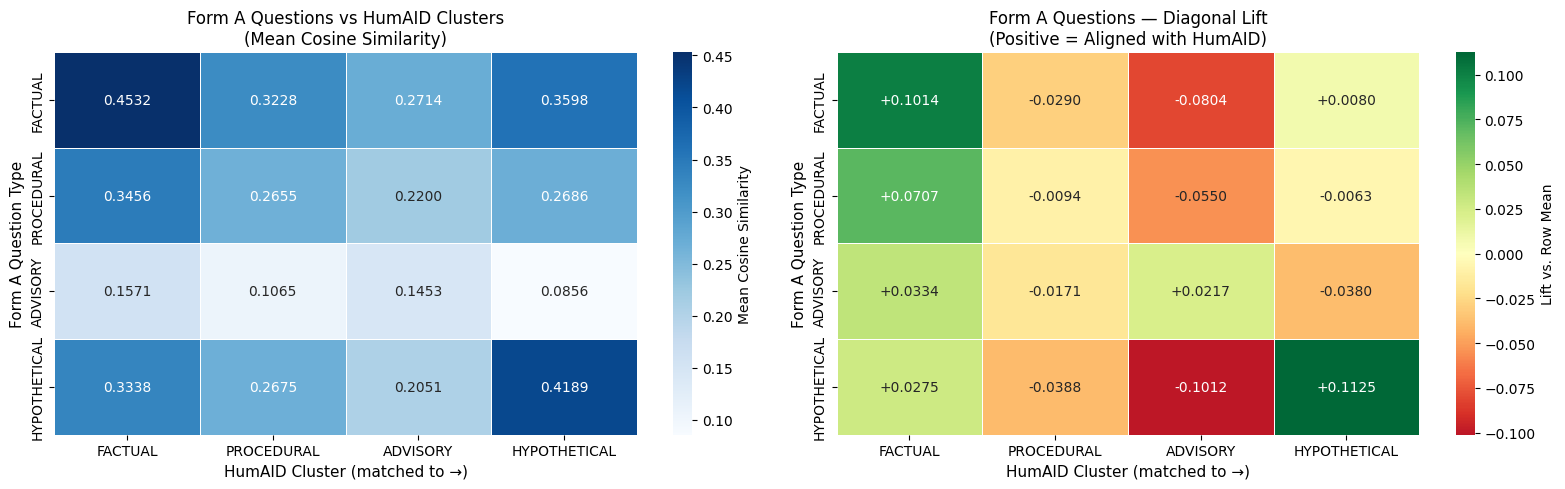


  FORM A — HUMAID SIMILARITY LIFT SUMMARY
  FACTUAL       : +0.1014  ✅ POSITIVE
  PROCEDURAL    : -0.0094  ⚠️  NEGATIVE
  ADVISORY      : +0.0217  ✅ POSITIVE
  HYPOTHETICAL  : +0.1125  ✅ POSITIVE
  Positive diagonal = question type aligns with
  real disaster discourse in that semantic domain.


In [ ]:
# ─── CELL 2: Similarity Analysis ────────────────────────────────────────────
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME)
print(f"Model loaded: {MODEL_NAME}")

# ── 1. Embed HumAID tweets (sample 15k for speed, reproducible) ─────────────
sample_tweets = humaid.sample(n=15000, random_state=42)["tweet_text"].tolist()
print("Embedding HumAID tweets...")
tweet_embs = model.encode(sample_tweets, batch_size=256, show_progress_bar=True,
                           normalize_embeddings=True)

# ── 2. KMeans k=4 on tweet embeddings ───────────────────────────────────────
print("Clustering...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tweet_embs)
centroids = kmeans.cluster_centers_

# ── 3. Embed Form A questions ────────────────────────────────────────────────
print("Embedding Form A questions...")
q_texts = qb["Question"].tolist()
q_types  = qb["Type"].tolist()
q_embs  = model.encode(q_texts, batch_size=64, show_progress_bar=True,
                        normalize_embeddings=True)

# ── 4. Auto-map cluster IDs to question types ────────────────────────────────
# For each question type, compute mean embedding → find closest cluster centroid
Q_TYPES = ["FACTUAL", "PROCEDURAL", "ADVISORY", "HYPOTHETICAL"]
type_centroids = {}
for qt in Q_TYPES:
    mask = [t == qt for t in q_types]
    type_centroids[qt] = np.mean(q_embs[mask], axis=0, keepdims=True)

# Each cluster → question type with highest cosine similarity to type centroid
sim_matrix = np.zeros((4, 4))
for c_idx, centroid in enumerate(centroids):
    for t_idx, qt in enumerate(Q_TYPES):
        sim_matrix[c_idx, t_idx] = cosine_similarity(
            centroid.reshape(1, -1), type_centroids[qt]
        )[0, 0]

# Greedy assignment (highest similarity first, each type used once)
from scipy.optimize import linear_sum_assignment
row_ind, col_ind = linear_sum_assignment(-sim_matrix)
cluster_to_type = {r: Q_TYPES[c] for r, c in zip(row_ind, col_ind)}
type_to_cluster = {v: k for k, v in cluster_to_type.items()}
print("\nCluster → Question Type mapping:")
for c, t in cluster_to_type.items():
    print(f"  Cluster {c} → {t}")

# ── 5. Per question-type, mean cosine similarity to each cluster centroid ────
# Shape: (4 question_types) × (4 clusters)
type_order = Q_TYPES
cluster_order = [type_to_cluster[qt] for qt in type_order]  # diagonal is "home" cluster

result = np.zeros((4, 4))
for t_idx, qt in enumerate(type_order):
    mask = np.array([t == qt for t in q_types])
    group_embs = q_embs[mask]
    for c_idx, c in enumerate(cluster_order):
        result[t_idx, c_idx] = cosine_similarity(group_embs, centroids[c].reshape(1, -1)).mean()

# ── 6. Lift = observed similarity / row mean (how much above random baseline) ─
row_means = result.mean(axis=1, keepdims=True)
lift = result - row_means  # positive diagonal = question type matches its HumAID cluster

# ── 7. Heatmap ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
sns.heatmap(result,
            xticklabels=type_order,
            yticklabels=type_order,
            annot=True, fmt=".4f", cmap="Blues",
            linewidths=0.5, ax=ax1, cbar_kws={"label": "Mean Cosine Similarity"})
ax1.set_xlabel("HumAID Cluster (matched to →)", fontsize=11)
ax1.set_ylabel("Form A Question Type", fontsize=11)
ax1.set_title("Form A Questions vs HumAID Clusters\n(Mean Cosine Similarity)", fontsize=12)

ax2 = axes[1]
colors = [["#d4edda" if v > 0 else "#f8d7da" for v in row] for row in lift]
sns.heatmap(lift,
            xticklabels=type_order,
            yticklabels=type_order,
            annot=True, fmt="+.4f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax2, cbar_kws={"label": "Lift vs. Row Mean"})
ax2.set_xlabel("HumAID Cluster (matched to →)", fontsize=11)
ax2.set_ylabel("Form A Question Type", fontsize=11)
ax2.set_title("Form A Questions — Diagonal Lift\n(Positive = Aligned with HumAID)", fontsize=12)

plt.tight_layout()
plt.savefig("forma_humaid_similarity.png", dpi=180, bbox_inches="tight")
plt.show()

# ── 8. Summary ───────────────────────────────────────────────────────────────
print("\n" + "=" * 52)
print("  FORM A — HUMAID SIMILARITY LIFT SUMMARY")
print("=" * 52)
for t_idx, qt in enumerate(type_order):
    diag_lift = lift[t_idx, t_idx]
    direction = "✅ POSITIVE" if diag_lift > 0 else "⚠️  NEGATIVE"
    print(f"  {qt:<14}: {diag_lift:+.4f}  {direction}")
print("=" * 52)
print("  Positive diagonal = question type aligns with")
print("  real disaster discourse in that semantic domain.")

In [ ]:
# ─── CELL 1: Setup + Load ───────────────────────────────────────────────────
!pip install -q groq google-generativeai mistralai openpyxl sentence-transformers

import pandas as pd
import numpy as np
import json, time, re
from google.colab import drive

# ── Paths ────────────────────────────────────────────────────────────────────
QB_PATH = "/content/Question_Bank_Curation.xlsx"

# ── Load FINAL BANK sheet ────────────────────────────────────────────────────
qb = pd.read_excel(QB_PATH, sheet_name="FINAL BANK", header=1)
qb.columns = ["Q_num", "Type", "Scenario", "Question", "Notes"]
qb = qb[qb["Question"].notna() & (qb["Question"].str.strip() != "")].reset_index(drop=True)
qb["Q_id"] = qb["Type"].str[:1] + qb["Q_num"].astype(str).str.zfill(2)

print(f"Loaded {len(qb)} questions")
print(qb["Type"].value_counts().to_string())
print()
print(qb[["Q_id","Type","Question"]].head(5).to_string(index=False))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 6.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.38.0 requires opentelemetry-api==1.38.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.38.0 requires opentelemetry-semantic-conventions==0.59b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
Loaded 100 questions
Type
FA

In [ ]:
# ─── CELL 2: Paraphrase Generation ──────────────────────────────────────────
from groq import Groq

GROQ_API_KEY = "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"
client = Groq(api_key=GROQ_API_KEY)

PARAPHRASE_PROMPT = """Generate exactly 10 paraphrases of the following disaster-related question.

Rules:
- Keep the same meaning and intent
- Vary sentence structure, word choice, and phrasing naturally
- Each must be a complete, standalone question
- Do not number them — return as a JSON array of 10 strings only

Question: {question}

Return format: ["paraphrase1", "paraphrase2", ..., "paraphrase10"]"""

def generate_paraphrases(question, retries=3):
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=[{"role": "user", "content": PARAPHRASE_PROMPT.format(question=question)}],
                temperature=0.8,
                max_tokens=1024,
            )
            text = response.choices[0].message.content.strip()
            # Extract JSON array
            match = re.search(r'\[.*\]', text, re.DOTALL)
            if match:
                paraphrases = json.loads(match.group())
                if len(paraphrases) == 10:
                    return paraphrases
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
            time.sleep(2)
    return [question] * 10  # fallback

# ── Run ───────────────────────────────────────────────────────────────────────
results = []
for i, row in qb.iterrows():
    print(f"[{i+1}/100] {row['Q_id']} — {row['Question'][:60]}...")
    paraphrases = generate_paraphrases(row["Question"])
    entry = {"Q_id": row["Q_id"], "Type": row["Type"], "Original": row["Question"]}
    for j, p in enumerate(paraphrases, 1):
        entry[f"P{j}"] = p
    results.append(entry)
    time.sleep(1.5)  # stay within free tier rate limit

paraphrase_df = pd.DataFrame(results)

# ── Save ──────────────────────────────────────────────────────────────────────
PARA_OUT = "/content/drive/MyDrive/paraphrases_forma.csv"
paraphrase_df.to_csv(PARA_OUT, index=False)
print(f"\nDone. Saved to {PARA_OUT}")
print(paraphrase_df[["Q_id","Original","P1","P2"]].head(3).to_string(index=False))

[1/100] F01 — Which areas are expected to be hit the hardest, and will my ...
[2/100] F02 — What is the safest evacuation route and where are the neares...
[3/100] F03 — How much time do I have to prepare, and what essential emerg...
[4/100] F04 — What is the predicted storm surge depth for my neighborhood?...
[5/100] F05 — Where can I access official typhoon evacuation maps for my a...
[6/100] F06 — Where is the nearest official storm shelter, and what is the...
[7/100] F07 — What is the fastest safe evacuation route out of my area?...
[8/100] F08 — How can I receive emergency updates if power and mobile netw...
[9/100] F09 — Is the typhoon forecast to make a direct hit on my town?...
[10/100] F10 — What items should I prepare to survive several days without ...
[11/100] F11 — What is the projected path of the typhoon and the flood risk...
[12/100] F12 — What roads are currently open and how long do I have to evac...
[13/100] F13 — Will electricity, water supply, and mobile networks r

In [ ]:
from google.colab import drive

In [ ]:
# ─── CELL 3: RQ1 — Within-Prompt Response Generation ────────────────────────
import os, time, csv
from groq import Groq
from mistralai.client import Mistral
from google.colab import drive

drive.mount('/content/drive')
# ── API Keys ─────────────────────────────────────────────────────────────────
GROQ_KEY    = "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"
MISTRAL_KEY = "b7Zd2n5jSkZVDQHmIunhiHhZuVC78kzi"

groq_client    = Groq(api_key=GROQ_KEY)
mistral_client = Mistral(api_key=MISTRAL_KEY)

MODELS = {
    "llama-4-scout":  ("groq", "meta-llama/llama-4-scout-17b-16e-instruct"),
    "llama-3.1-8b":   ("groq", "llama-3.1-8b-instant"),
    "mistral-7b":     ("mistral", "mistral-small-latest"),
}

K_REPEATS = 5
SYSTEM_PROMPT = "You are a disaster response advisory assistant. Answer the question clearly and concisely based on standard emergency management guidance."
OUT_PATH = "/content/drive/MyDrive/rq1_responses.csv"

# ── API call functions ────────────────────────────────────────────────────────
def call_groq(model_id, question):
    r = groq_client.chat.completions.create(
        model=model_id,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": question}
        ],
        temperature=0.7, max_tokens=512
    )
    return r.choices[0].message.content.strip()

def call_mistral(model_id, question):
    r = mistral_client.chat.complete(
        model=model_id,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": question}
        ],
        temperature=0.7, max_tokens=512
    )
    return r.choices[0].message.content.strip()

def call_model(model_name, question):
    backend, model_id = MODELS[model_name]
    if backend == "groq":
        return call_groq(model_id, question)
    elif backend == "mistral":
        return call_mistral(model_id, question)

# ── Run ───────────────────────────────────────────────────────────────────────
done = set()
if os.path.exists(OUT_PATH):
    existing = pd.read_csv(OUT_PATH)
    done = set(zip(existing["Q_id"], existing["model"], existing["repeat"]))
    print(f"Resuming — {len(done)} calls already done")

fieldnames = ["Q_id", "Type", "Question", "model", "repeat", "response"]
with open(OUT_PATH, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not done:
        writer.writeheader()

    total = len(qb) * len(MODELS) * K_REPEATS
    done_count = len(done)

    for _, row in qb.iterrows():
        for model_name in MODELS:
            for k in range(1, K_REPEATS + 1):
                if (row["Q_id"], model_name, k) in done:
                    continue
                try:
                    response = call_model(model_name, row["Question"])
                    writer.writerow({
                        "Q_id": row["Q_id"], "Type": row["Type"],
                        "Question": row["Question"], "model": model_name,
                        "repeat": k, "response": response
                    })
                    f.flush()
                    done_count += 1
                    if done_count % 15 == 0:
                        print(f"  [{done_count}/{total}] {row['Q_id']} | {model_name} | rep {k}")
                    time.sleep(1.2)
                except Exception as e:
                    print(f"  ERROR {row['Q_id']} {model_name} rep {k}: {e}")
                    time.sleep(5)

print(f"\nDone. {done_count} responses saved to {OUT_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Resuming — 1274 calls already done
  [1275/1500] F01 | llama-4-scout | rep 1
  [1290/1500] F04 | llama-4-scout | rep 1
  [1305/1500] F07 | llama-4-scout | rep 1
  [1320/1500] F10 | llama-4-scout | rep 1
  [1335/1500] F13 | llama-4-scout | rep 1
  [1350/1500] F16 | llama-4-scout | rep 1
  [1365/1500] F19 | llama-4-scout | rep 1
  [1380/1500] F22 | llama-4-scout | rep 1
  [1395/1500] F25 | llama-4-scout | rep 1
  [1410/1500] P28 | llama-4-scout | rep 1
  [1425/1500] P31 | llama-4-scout | rep 1
  [1440/1500] P34 | llama-4-scout | rep 1
  [1455/1500] P37 | llama-4-scout | rep 1
  [1470/1500] P40 | llama-4-scout | rep 1
  [1485/1500] P43 | llama-4-scout | rep 1
  [1500/1500] P46 | llama-4-scout | rep 1
  [1515/1500] P49 | llama-4-scout | rep 1
  [1530/1500] A52 | llama-4-scout | rep 1
  [1545/1500] A55 | llama-4-scout | rep 1
  [1560/1500] A58 | llama-4-scout | re

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.7 MB/s eta 0:00:00
Total responses: 1500
model
llama-3.1-8b     500
llama-4-scout    500
mistral-7b       500


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  [50/300] done...
  [100/300] done...
  [150/300] done...
  [200/300] done...
  [250/300] done...
  [300/300] done...

Metrics computed for 300 question-model pairs
                 SAS  ROUGE_L     CR
model                               
llama-3.1-8b   0.879    0.312  0.774
llama-4-scout  0.917    0.465  0.916
mistral-7b     0.880    0.322  0.759


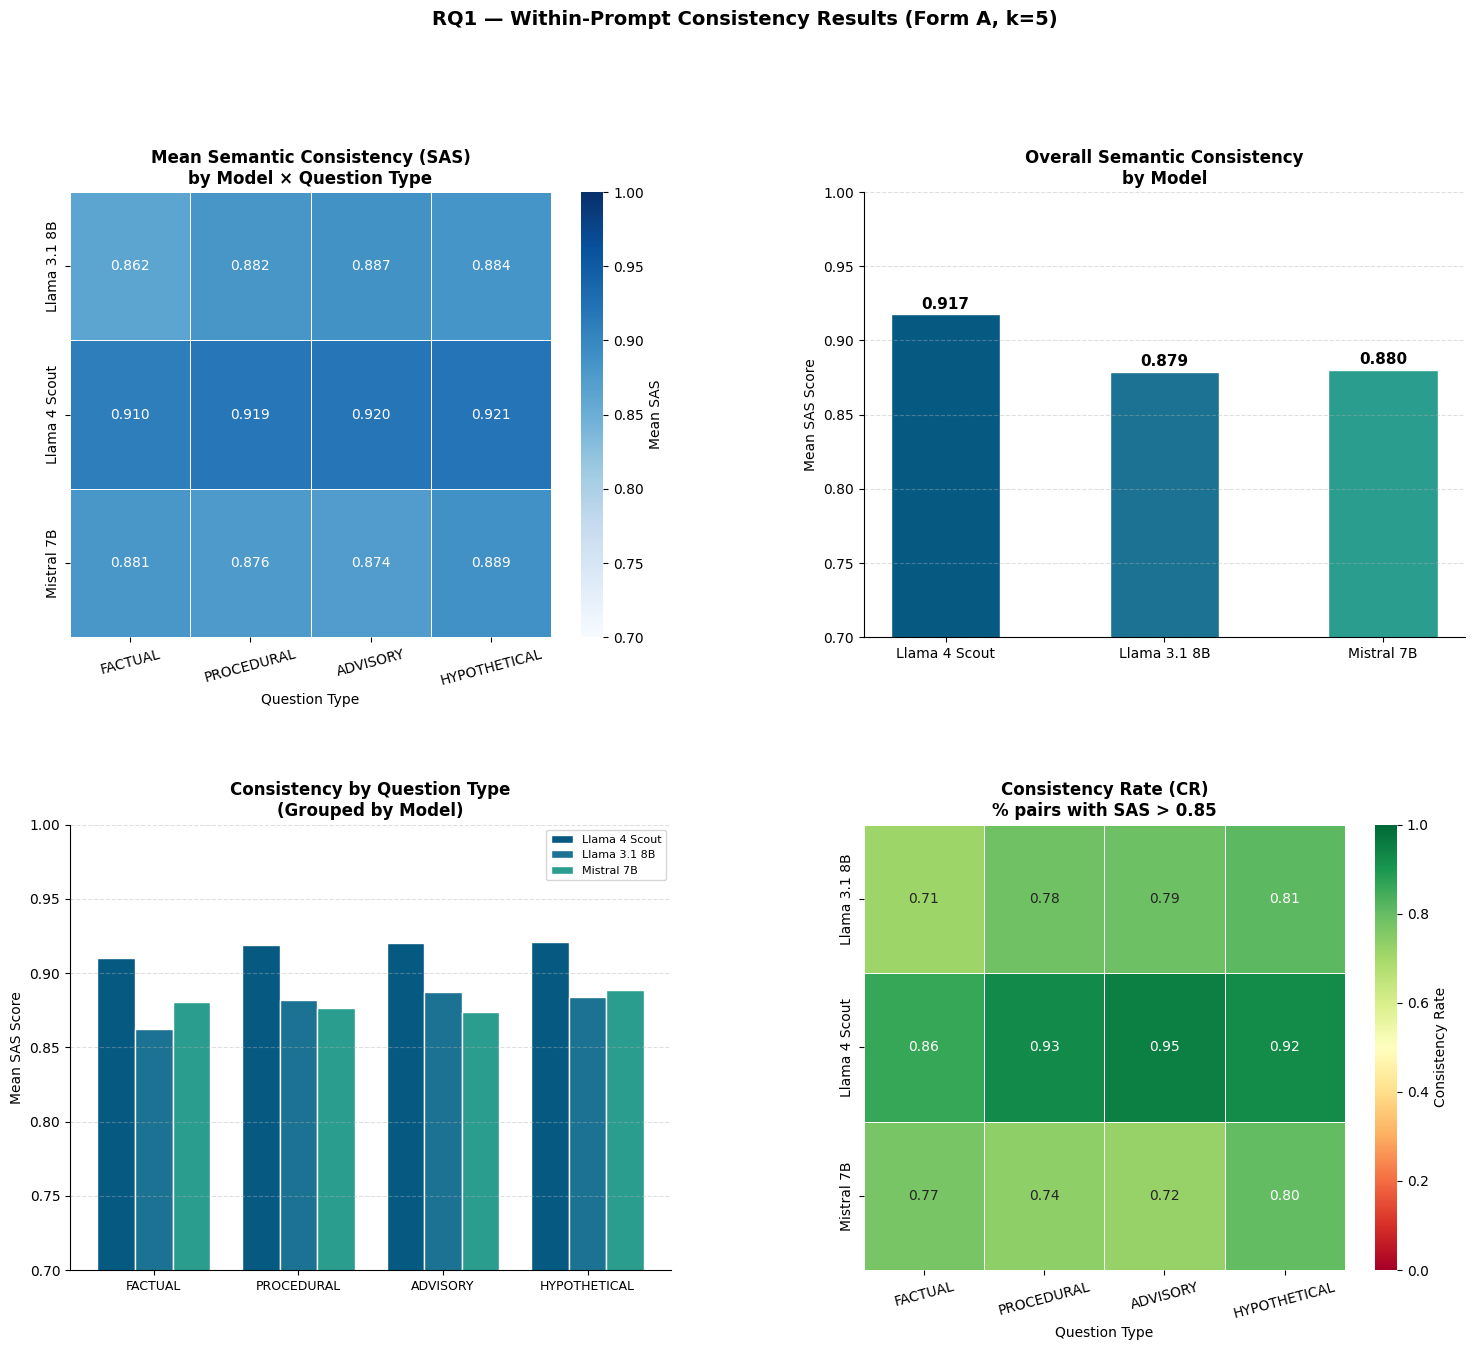


Saved: rq1_results.png + rq1_metrics.csv


In [ ]:
# ─── CELL 4: Consistency Metrics (RQ1) ──────────────────────────────────────
!pip install -q rouge-score bert-score sentence-transformers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from rouge_score import rouge_scorer
import warnings
warnings.filterwarnings("ignore")

# ── Load responses ────────────────────────────────────────────────────────────
df = pd.read_csv("/content/drive/MyDrive/rq1_responses.csv")

# Keep only the 3 complete models
MODELS = ["llama-4-scout", "llama-3.1-8b", "mistral-7b"]
df = df[df["model"].isin(MODELS)].copy()
print(f"Total responses: {len(df)}")
print(df.groupby("model")["Q_id"].count().to_string())

# ── Load embedding model ──────────────────────────────────────────────────────
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

# ── Compute per-question consistency scores ───────────────────────────────────
records = []

groups = df.groupby(["Q_id", "Type", "model"])
total = len(groups)

for i, ((qid, qtype, model), grp) in enumerate(groups):
    responses = grp["response"].dropna().tolist()
    if len(responses) < 2:
        continue

    # 1. SAS — mean pairwise cosine similarity (primary semantic metric)
    embs = embedder.encode(responses, normalize_embeddings=True)
    pairs = list(combinations(range(len(embs)), 2))
    sas_scores = [cosine_similarity(embs[a].reshape(1,-1), embs[b].reshape(1,-1))[0][0]
                  for a, b in pairs]
    sas = float(np.mean(sas_scores))

    # 2. ROUGE-L — mean pairwise
    rl_scores = [rouge.score(responses[a], responses[b])["rougeL"].fmeasure
                 for a, b in pairs]
    rougeL = float(np.mean(rl_scores))

    # 3. Semantic Variance — std of embedding centroid distances
    centroid = embs.mean(axis=0)
    dists = [float(np.linalg.norm(e - centroid)) for e in embs]
    sem_var = float(np.std(dists))

    # 4. Consistency Rate — proportion of pairs with SAS > 0.85
    cr = float(np.mean([s > 0.85 for s in sas_scores]))

    records.append({
        "Q_id": qid, "Type": qtype, "model": model,
        "SAS": round(sas, 4),
        "ROUGE_L": round(rougeL, 4),
        "Sem_Var": round(sem_var, 4),
        "CR": round(cr, 4),
        "n_responses": len(responses),
    })

    if (i + 1) % 50 == 0:
        print(f"  [{i+1}/{total}] done...")

results_df = pd.DataFrame(records)
results_df.to_csv("/content/drive/MyDrive/rq1_metrics.csv", index=False)
print(f"\nMetrics computed for {len(results_df)} question-model pairs")
print(results_df.groupby("model")[["SAS","ROUGE_L","CR"]].mean().round(3).to_string())

# ── VISUALIZATIONS ────────────────────────────────────────────────────────────
Q_TYPES  = ["FACTUAL","PROCEDURAL","ADVISORY","HYPOTHETICAL"]
MODEL_LABELS = {"llama-4-scout": "Llama 4 Scout", "llama-3.1-8b": "Llama 3.1 8B", "mistral-7b": "Mistral 7B"}
COLORS   = {"llama-4-scout": "#065A82", "llama-3.1-8b": "#1C7293", "mistral-7b": "#2A9D8F"}

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# ── Plot 1: Heatmap — SAS by model × question type ───────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
pivot = results_df.pivot_table(values="SAS", index="model", columns="Type", aggfunc="mean")
pivot = pivot.reindex(columns=Q_TYPES)
pivot.index = [MODEL_LABELS[m] for m in pivot.index]
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues", ax=ax1,
            linewidths=0.5, cbar_kws={"label": "Mean SAS"},
            vmin=0.7, vmax=1.0)
ax1.set_title("Mean Semantic Consistency (SAS)\nby Model × Question Type", fontsize=12, fontweight="bold")
ax1.set_xlabel("Question Type", fontsize=10)
ax1.set_ylabel("")
ax1.tick_params(axis="x", rotation=15)

# ── Plot 2: Bar chart — Overall SAS per model ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
model_means = results_df.groupby("model")["SAS"].mean().reindex(MODELS)
bars = ax2.bar([MODEL_LABELS[m] for m in MODELS], model_means.values,
               color=[COLORS[m] for m in MODELS], edgecolor="white", width=0.5)
for bar, val in zip(bars, model_means.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.set_ylim(0.7, 1.0)
ax2.set_ylabel("Mean SAS Score", fontsize=10)
ax2.set_title("Overall Semantic Consistency\nby Model", fontsize=12, fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)
ax2.yaxis.grid(True, linestyle="--", alpha=0.4)

# ── Plot 3: Grouped bar — SAS per question type per model ────────────────────
ax3 = fig.add_subplot(gs[1, 0])
x = np.arange(len(Q_TYPES))
width = 0.26
for j, model in enumerate(MODELS):
    vals = [results_df[(results_df["model"]==model) & (results_df["Type"]==qt)]["SAS"].mean()
            for qt in Q_TYPES]
    ax3.bar(x + j*width, vals, width, label=MODEL_LABELS[model],
            color=COLORS[model], edgecolor="white")
ax3.set_xticks(x + width)
ax3.set_xticklabels(Q_TYPES, fontsize=9)
ax3.set_ylim(0.7, 1.0)
ax3.set_ylabel("Mean SAS Score", fontsize=10)
ax3.set_title("Consistency by Question Type\n(Grouped by Model)", fontsize=12, fontweight="bold")
ax3.legend(fontsize=8)
ax3.spines[["top","right"]].set_visible(False)
ax3.yaxis.grid(True, linestyle="--", alpha=0.4)

# ── Plot 4: Consistency Rate heatmap ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
pivot_cr = results_df.pivot_table(values="CR", index="model", columns="Type", aggfunc="mean")
pivot_cr = pivot_cr.reindex(columns=Q_TYPES)
pivot_cr.index = [MODEL_LABELS[m] for m in pivot_cr.index]
sns.heatmap(pivot_cr, annot=True, fmt=".2f", cmap="RdYlGn", ax=ax4,
            linewidths=0.5, cbar_kws={"label": "Consistency Rate"},
            vmin=0.0, vmax=1.0)
ax4.set_title("Consistency Rate (CR)\n% pairs with SAS > 0.85", fontsize=12, fontweight="bold")
ax4.set_xlabel("Question Type", fontsize=10)
ax4.set_ylabel("")
ax4.tick_params(axis="x", rotation=15)

plt.suptitle("RQ1 — Within-Prompt Consistency Results (Form A, k=5)",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("/content/drive/MyDrive/rq1_results.png", dpi=180, bbox_inches="tight")
plt.show()
print("\nSaved: rq1_results.png + rq1_metrics.csv")